In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import ast
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.transforms import functional as TF
import torchvision.models as models
import pickle

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla P100-PCIE-16GB
VRAM: 17.1 GB


In [2]:
DATASET_PATH = Path("/kaggle/input/datasets/steubk/wikiart")
df = pd.read_csv(DATASET_PATH / "classes.csv")

df['genre_parsed'] = df['genre'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
df['genre_primary'] = df['genre_parsed'].apply(lambda x: x[0] if len(x) > 0 else None)

df['style'] = df['filename'].apply(lambda x: x.split('/')[0])

df['filepath'] = df['filename'].apply(lambda x: str(DATASET_PATH / x))

le_style = LabelEncoder()
le_artist = LabelEncoder()
le_genre = LabelEncoder()

df['style_idx'] = le_style.fit_transform(df['style'])
df['artist_idx'] = le_artist.fit_transform(df['artist'])

# Genre has some nulls — handle them
df_genre = df[df['genre_primary'].notna()].copy()
df_genre['genre_idx'] = le_genre.fit_transform(df_genre['genre_primary'])

print(f"Total samples: {len(df)}")
print(f"Samples with genre: {len(df_genre)}")
print(f"Style classes: {df['style'].nunique()}")
print(f"Artist classes: {df['artist'].nunique()}")
print(f"Genre classes: {df['genre_primary'].nunique()}")
print(f"\nSubset distribution:\n{df['subset'].value_counts()}")
print(f"\nMulti-genre paintings: {(df['genre_count'] > 1).sum()}")

Total samples: 80042
Samples with genre: 80042
Style classes: 27
Artist classes: 1119
Genre classes: 27

Subset distribution:
subset
train               63998
test                16000
uncertain artist       44
Name: count, dtype: int64

Multi-genre paintings: 1400


In [3]:
print("=== Genre vs Style overlap check ===")
print("\nUnique genres:")
print(sorted(df['genre_primary'].unique()))

print("\nUnique styles:")
print(sorted(df['style'].unique()))

df['genre_clean'] = df['genre_primary'].str.replace(' ', '_').str.replace('/', '_')
df['genre_matches_style'] = df['genre_clean'] == df['style']
print(f"\nPaintings where genre label == style label: {df['genre_matches_style'].sum()} / {len(df)} ({df['genre_matches_style'].mean()*100:.1f}%)")

print("\nSample of genre values that differ from style:")
diff = df[~df['genre_matches_style']][['style', 'genre_primary', 'artist']].head(20)
print(diff.to_string())

=== Genre vs Style overlap check ===

Unique genres:
['Abstract Expressionism', 'Action painting', 'Analytical Cubism', 'Art Nouveau Modern', 'Baroque', 'Color Field Painting', 'Contemporary Realism', 'Cubism', 'Early Renaissance', 'Expressionism', 'Fauvism', 'High Renaissance', 'Impressionism', 'Mannerism Late Renaissance', 'Minimalism', 'Naive Art Primitivism', 'New Realism', 'Northern Renaissance', 'Pointillism', 'Pop Art', 'Post Impressionism', 'Realism', 'Rococo', 'Romanticism', 'Symbolism', 'Synthetic Cubism', 'Ukiyo e']

Unique styles:
['Abstract_Expressionism', 'Action_painting', 'Analytical_Cubism', 'Art_Nouveau_Modern', 'Baroque', 'Color_Field_Painting', 'Contemporary_Realism', 'Cubism', 'Early_Renaissance', 'Expressionism', 'Fauvism', 'High_Renaissance', 'Impressionism', 'Mannerism_Late_Renaissance', 'Minimalism', 'Naive_Art_Primitivism', 'New_Realism', 'Northern_Renaissance', 'Pointillism', 'Pop_Art', 'Post_Impressionism', 'Realism', 'Rococo', 'Romanticism', 'Symbolism', 'S

In [4]:
artist_counts = df[df['subset'] != 'uncertain artist']['artist'].value_counts()

thresholds = [1, 5, 10, 20, 50]
print("Artist filtering analysis:")
print(f"{'Min samples':>12} | {'Artists kept':>12} | {'Paintings kept':>14} | {'% data kept':>11}")
print("-" * 55)
for t in thresholds:
    kept_artists = (artist_counts >= t).sum()
    kept_paintings = artist_counts[artist_counts >= t].sum()
    print(f"{t:>12} | {kept_artists:>12} | {kept_paintings:>14} | {kept_paintings/len(df)*100:>10.1f}%")

Artist filtering analysis:
 Min samples | Artists kept | Paintings kept | % data kept
-------------------------------------------------------
           1 |         1119 |          79998 |       99.9%
           5 |         1039 |          79814 |       99.7%
          10 |          976 |          79389 |       99.2%
          20 |          726 |          75605 |       94.5%
          50 |          374 |          64501 |       80.6%


In [5]:
wdf = pd.read_csv(DATASET_PATH / "wclasses.csv")

print(f"wclasses shape: {wdf.shape}")
print(f"Unique genre values in wclasses: {wdf['genre'].nunique()}")
print(f"Genre value range: {wdf['genre'].min()} to {wdf['genre'].max()}")
print(f"\nGenre value counts (top 20):\n{wdf['genre'].value_counts().head(20)}")
print(f"\nUnique style values: {wdf['style'].nunique()}")
print(f"Style value range: {wdf['style'].min()} to {wdf['style'].max()}")

wdf['basename'] = wdf['file'].apply(lambda x: x.split('/')[-1])
df['basename'] = df['filename'].apply(lambda x: x.split('/')[-1])

merged = df.merge(wdf[['basename', 'genre']], on='basename', how='inner', suffixes=('_classes', '_w'))
print(f"\nMerged rows: {len(merged)}")
print(f"\nSample of wclasses genre integers vs our style labels:")
print(merged[['style', 'artist', 'genre_w']].head(20).to_string())

wclasses shape: (81444, 4)
Unique genre values in wclasses: 11
Genre value range: 129 to 139

Genre value counts (top 20):
genre
139    16452
135    14112
133    13358
131    10859
136     6538
129     4968
130     4602
137     3942
138     2788
134     1923
132     1902
Name: count, dtype: int64

Unique style values: 27
Style value range: 140 to 166

Merged rows: 81364

Sample of wclasses genre integers vs our style labels:
                     style         artist  genre_w
0   Abstract_Expressionism  aaron siskind      139
1   Abstract_Expressionism  aaron siskind      139
2   Abstract_Expressionism  aaron siskind      139
3   Abstract_Expressionism  aaron siskind      139
4   Abstract_Expressionism  aaron siskind      139
5   Abstract_Expressionism  aaron siskind      139
6   Abstract_Expressionism  aaron siskind      139
7   Abstract_Expressionism  aaron siskind      139
8   Abstract_Expressionism  aaron siskind      139
9   Abstract_Expressionism  aaron siskind      139
10  Abstra

In [6]:
MIN_ARTIST_SAMPLES = 20

df_clean = df[df['subset'] != 'uncertain artist'].copy()

artist_counts = df_clean['artist'].value_counts()
valid_artists = artist_counts[artist_counts >= MIN_ARTIST_SAMPLES].index
df_clean = df_clean[df_clean['artist'].isin(valid_artists)].copy()

le_style = LabelEncoder()
le_artist = LabelEncoder()

df_clean['style_idx'] = le_style.fit_transform(df_clean['style'])
df_clean['artist_idx'] = le_artist.fit_transform(df_clean['artist'])

df_train = df_clean[df_clean['subset'] == 'train'].copy()
df_test = df_clean[df_clean['subset'] == 'test'].copy()

print(f"Train: {len(df_train)} samples")
print(f"Test:  {len(df_test)} samples")
print(f"Style classes: {df_clean['style'].nunique()}")
print(f"Artist classes: {df_clean['artist'].nunique()}")

import pickle
with open('le_style.pkl', 'wb') as f:
    pickle.dump(le_style, f)
with open('le_artist.pkl', 'wb') as f:
    pickle.dump(le_artist, f)

print("\nLabel encoders saved.")
print(f"\nStyle classes: {list(le_style.classes_)}")

Train: 60484 samples
Test:  15121 samples
Style classes: 27
Artist classes: 726

Label encoders saved.

Style classes: ['Abstract_Expressionism', 'Action_painting', 'Analytical_Cubism', 'Art_Nouveau_Modern', 'Baroque', 'Color_Field_Painting', 'Contemporary_Realism', 'Cubism', 'Early_Renaissance', 'Expressionism', 'Fauvism', 'High_Renaissance', 'Impressionism', 'Mannerism_Late_Renaissance', 'Minimalism', 'Naive_Art_Primitivism', 'New_Realism', 'Northern_Renaissance', 'Pointillism', 'Pop_Art', 'Post_Impressionism', 'Realism', 'Rococo', 'Romanticism', 'Symbolism', 'Synthetic_Cubism', 'Ukiyo_e']


In [7]:
GENRE_MAP = {
    129: 'abstract',
    130: 'cityscape',
    131: 'genre_painting',
    132: 'illustration',
    133: 'landscape',
    134: 'nude_painting',
    135: 'portrait',
    136: 'religious_painting',
    137: 'sketch_and_study',
    138: 'still_life',
    139: None
}

In [8]:
wdf = pd.read_csv(DATASET_PATH / "wclasses.csv")
wdf['genre_name'] = wdf['genre'].map(GENRE_MAP)
wdf['basename'] = wdf['file'].apply(lambda x: x.split('/')[-1])

df_clean['basename'] = df_clean['filename'].apply(lambda x: x.split('/')[-1])

df_clean = df_clean.merge(
    wdf[['basename', 'genre_name']],
    on='basename',
    how='left'
)
le_genre = LabelEncoder()
mask = df_clean['genre_name'].notna()
df_clean.loc[mask, 'genre_idx'] = le_genre.fit_transform(df_clean.loc[mask, 'genre_name'])
df_clean['genre_idx'] = df_clean['genre_idx'].astype('Int64')  # nullable integer, NaN stays NaN

with open('le_genre.pkl', 'wb') as f:
    pickle.dump(le_genre, f)

df_train = df_clean[df_clean['subset'] == 'train'].copy()
df_test  = df_clean[df_clean['subset'] == 'test'].copy()

print(f"Train: {len(df_train)}")
print(f"Test:  {len(df_test)}")
print(f"\nGenre label coverage:")
print(f"  Train — known: {df_train['genre_name'].notna().sum()}, unknown: {df_train['genre_name'].isna().sum()}")
print(f"  Test  — known: {df_test['genre_name'].notna().sum()},  unknown: {df_test['genre_name'].isna().sum()}")
print(f"\nGenre classes ({df_clean['genre_name'].nunique()} total):")
print(df_clean['genre_name'].value_counts())

Train: 61534
Test:  15374

Genre label coverage:
  Train — known: 49590, unknown: 11944
  Test  — known: 12375,  unknown: 2999

Genre classes (10 total):
genre_name
portrait              13538
landscape             12959
genre_painting        10563
religious_painting     6291
cityscape              4458
abstract               3960
sketch_and_study       3880
still_life             2597
illustration           1880
nude_painting          1839
Name: count, dtype: int64


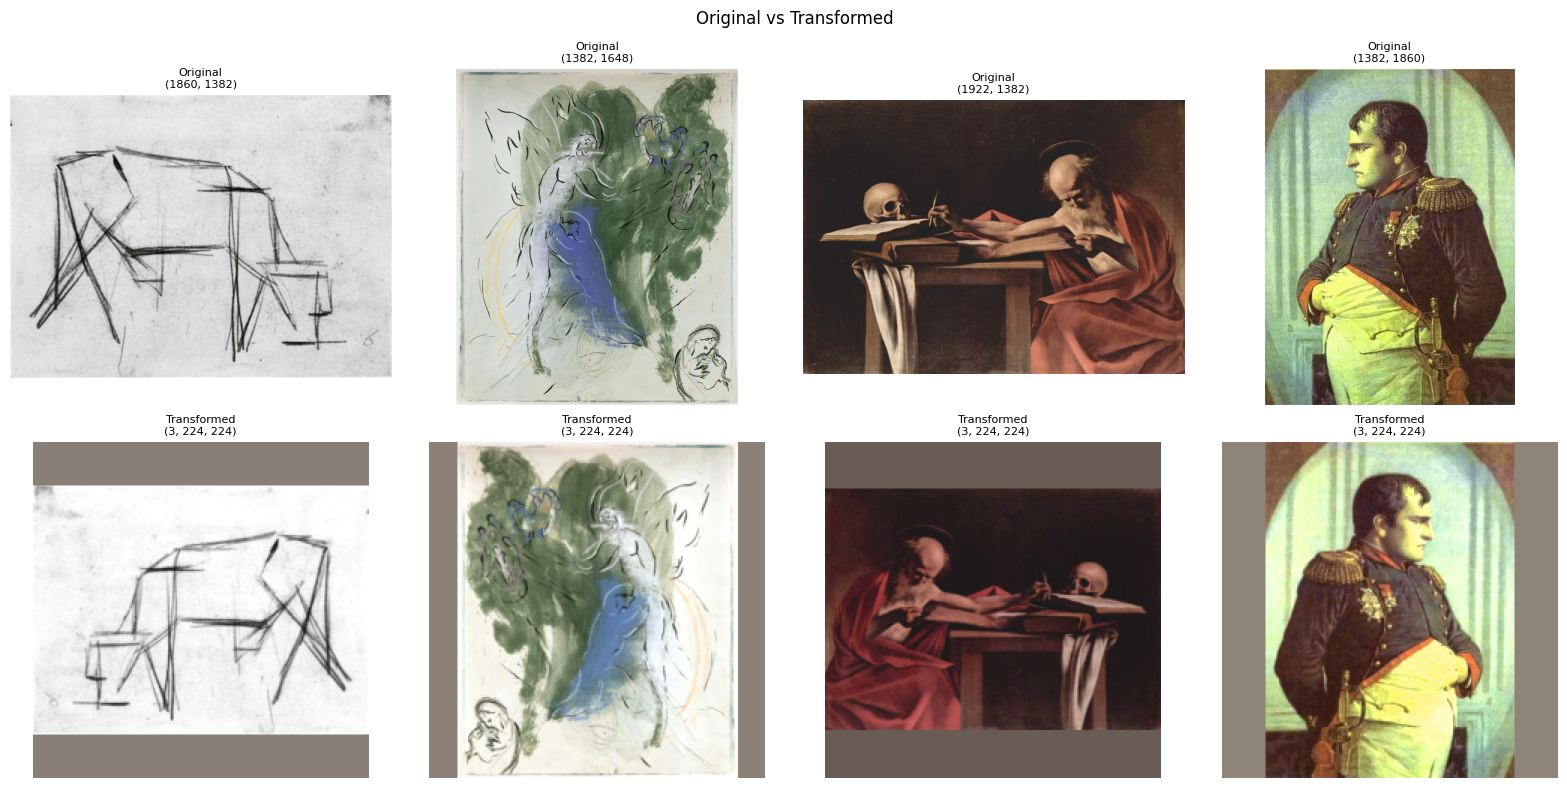

In [9]:
from torchvision import transforms
from PIL import Image, ImageOps
import torch

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE = 224

class PadToSquare:
    """
    Resize longest side to IMG_SIZE preserving aspect ratio,
    then pad shorter side to make it square.
    Uses ImageNet mean as padding color so padded regions are 
    effectively 'invisible' after normalization.
    """
    def __init__(self, size):
        self.size = size

    def __call__(self, img):
        w, h = img.size
        scale = self.size / max(w, h)
        new_w = int(w * scale)
        new_h = int(h * scale)
        img = img.resize((new_w, new_h), Image.BILINEAR)

        pad_w = self.size - new_w
        pad_h = self.size - new_h
        padding = (pad_w // 2, pad_h // 2, 
                   pad_w - pad_w // 2, pad_h - pad_h // 2)
        fill = tuple(int(m * 255) for m in IMAGENET_MEAN)
        img = ImageOps.expand(img, border=padding, fill=fill)
        return img


train_transforms = transforms.Compose([
    PadToSquare(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, 
                           saturation=0.1, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

test_transforms = transforms.Compose([
    PadToSquare(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

def denormalize(tensor):
    """Reverse normalization for visualization"""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
samples = df_train.sample(4, random_state=42)

for i, (_, row) in enumerate(samples.iterrows()):
    img = Image.open(row['filepath']).convert('RGB')
    
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Original\n{img.size}", fontsize=8)
    axes[0, i].axis('off')
    
    transformed = train_transforms(img)
    axes[1, i].imshow(denormalize(transformed).permute(1, 2, 0))
    axes[1, i].set_title(f"Transformed\n{tuple(transformed.shape)}", fontsize=8)
    axes[1, i].axis('off')

plt.suptitle('Original vs Transformed', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
class WikiArtDataset(Dataset):
    def __init__(self, df, transform=None):
        """
        df: dataframe with columns:
            filepath, style_idx, artist_idx, genre_idx (nullable Int64)
        transform: torchvision transform pipeline
        """
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row['filepath']).convert('RGB')
        if self.transform:
            img = self.transform(img)

        style_idx  = torch.tensor(row['style_idx'],  dtype=torch.long)
        artist_idx = torch.tensor(row['artist_idx'], dtype=torch.long)

        if pd.isna(row['genre_idx']):
            genre_idx = torch.tensor(-1, dtype=torch.long)
        else:
            genre_idx = torch.tensor(int(row['genre_idx']), dtype=torch.long)

        return img, style_idx, artist_idx, genre_idx

In [11]:
print("Checking file existence — this may take a minute...")

df_clean['file_exists'] = df_clean['filepath'].apply(lambda p: Path(p).exists())

missing = (~df_clean['file_exists']).sum()
print(f"Total files:   {len(df_clean)}")
print(f"Files found:   {df_clean['file_exists'].sum()}")
print(f"Files missing: {missing}")

print("\nSample missing files:")
print(df_clean[~df_clean['file_exists']]['filepath'].head(10).tolist())

df_clean = df_clean[df_clean['file_exists']].copy()
df_train = df_clean[df_clean['subset'] == 'train'].copy()
df_test  = df_clean[df_clean['subset'] == 'test'].copy()

print(f"\nAfter filtering:")
print(f"Train: {len(df_train)}")
print(f"Test:  {len(df_test)}")

Checking file existence — this may take a minute...
Total files:   76908
Files found:   76268
Files missing: 640

Sample missing files:
['/kaggle/input/datasets/steubk/wikiart/Art_Nouveau_Modern/eugã¨ne-grasset_a-la-place-clichy.jpg', '/kaggle/input/datasets/steubk/wikiart/Art_Nouveau_Modern/eugã¨ne-grasset_abricotine.jpg', '/kaggle/input/datasets/steubk/wikiart/Art_Nouveau_Modern/eugã¨ne-grasset_affiche-pour-the-century-magazine-napol-on.jpg', '/kaggle/input/datasets/steubk/wikiart/Art_Nouveau_Modern/eugã¨ne-grasset_anxi-t-1897.jpg', '/kaggle/input/datasets/steubk/wikiart/Art_Nouveau_Modern/eugã¨ne-grasset_bonne-nouvelle.jpg', '/kaggle/input/datasets/steubk/wikiart/Art_Nouveau_Modern/eugã¨ne-grasset_encre-l-marquet.jpg', '/kaggle/input/datasets/steubk/wikiart/Art_Nouveau_Modern/eugã¨ne-grasset_esclarmonde.jpg', '/kaggle/input/datasets/steubk/wikiart/Art_Nouveau_Modern/eugã¨ne-grasset_froideur.jpg', '/kaggle/input/datasets/steubk/wikiart/Art_Nouveau_Modern/eugã¨ne-grasset_girl-in-the-g

In [12]:
# Re-encode after file filtering — index may have shifted
le_style  = LabelEncoder()
le_artist = LabelEncoder()
le_genre  = LabelEncoder()

df_clean['style_idx']  = le_style.fit_transform(df_clean['style'])
df_clean['artist_idx'] = le_artist.fit_transform(df_clean['artist'])

mask = df_clean['genre_name'].notna()
df_clean.loc[mask, 'genre_idx'] = le_genre.fit_transform(df_clean.loc[mask, 'genre_name'])
df_clean['genre_idx'] = df_clean['genre_idx'].astype('Int64')
df_train = df_clean[df_clean['subset'] == 'train'].copy()
df_test  = df_clean[df_clean['subset'] == 'test'].copy()
with open('le_style.pkl', 'wb') as f:
    pickle.dump(le_style, f)
with open('le_artist.pkl', 'wb') as f:
    pickle.dump(le_artist, f)
with open('le_genre.pkl', 'wb') as f:
    pickle.dump(le_genre, f)

print(f"Style classes:  {df_clean['style'].nunique()}")
print(f"Artist classes: {df_clean['artist'].nunique()}")
print(f"Genre classes:  {df_clean['genre_name'].nunique()}")

Style classes:  27
Artist classes: 720
Genre classes:  10


In [13]:
train_dataset = WikiArtDataset(df_train, transform=train_transforms)
test_dataset  = WikiArtDataset(df_test,  transform=test_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Confirm clean batch loads with correct label ranges
imgs, styles, artists, genres = next(iter(train_loader))
print(f"Batch shapes: {imgs.shape}")
print(f"Style  range in batch: {styles.min().item()} - {styles.max().item()}")
print(f"Artist range in batch: {artists.min().item()} - {artists.max().item()}")
print(f"Genre unknowns in batch: {(genres == -1).sum().item()}")

Batch shapes: torch.Size([64, 3, 224, 224])
Style  range in batch: 0 - 26
Artist range in batch: 14 - 672
Genre unknowns in batch: 10


In [14]:
from sklearn.utils.class_weight import compute_class_weight

def get_class_weights(labels, n_classes, device):
    labels_clean = labels[labels >= 0] 
    classes = np.arange(n_classes)
    weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=labels_clean
    )
    return torch.tensor(weights, dtype=torch.float32).to(device)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

style_weights  = get_class_weights(
    df_train['style_idx'].values, 
    df_clean['style'].nunique(), 
    device
)
artist_weights = get_class_weights(
    df_train['artist_idx'].values, 
    df_clean['artist'].nunique(), 
    device
)
genre_weights  = get_class_weights(
    df_train['genre_idx'].dropna().astype(int).values, 
    df_clean['genre_name'].nunique(), 
    device
)

print(f"Style weights  — min: {style_weights.min():.3f},  max: {style_weights.max():.3f}")
print(f"Artist weights — min: {artist_weights.min():.3f}, max: {artist_weights.max():.3f}")
print(f"Genre weights  — min: {genre_weights.min():.3f},  max: {genre_weights.max():.3f}")

Device: cuda
Style weights  — min: 0.226,  max: 32.286
Artist weights — min: 0.056, max: 5.297
Genre weights  — min: 0.455,  max: 3.352


In [15]:
class HorizontalBiGRU(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True
        )

    def forward(self, x):
        B, C, H, W = x.shape
        x = x.permute(0, 2, 3, 1)          # (B, H, W, C)
        x = x.reshape(B * H, W, C)          # (B*H, W, C) — W is sequence length
        x, _ = self.gru(x)                  # (B*H, W, hidden*2)
        x = x.reshape(B, H, W, -1)          # (B, H, W, hidden*2)
        return x


class VerticalBiGRU(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True
        )

    def forward(self, x):
        B, H, W, C = x.shape
        x = x.permute(0, 2, 1, 3)          # (B, W, H, C)
        x = x.reshape(B * W, H, C)          # (B*W, H, C) — H is sequence length
        x, _ = self.gru(x)                  # (B*W, H, hidden*2)
        x = x.reshape(B, W, H, -1)          # (B, W, H, hidden*2)
        x = x.permute(0, 2, 1, 3)          # (B, H, W, hidden*2)
        return x

In [16]:
class MultiTaskHeads(nn.Module):
    def __init__(self, input_dim, n_styles, n_artists, n_genres, dropout=0.4):
        super().__init__()
        self.embedding = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.style_head  = nn.Linear(256, n_styles)
        self.artist_head = nn.Linear(256, n_artists)
        self.genre_head  = nn.Linear(256, n_genres)

    def forward(self, x):
        emb = self.embedding(x)
        return (
            self.style_head(emb),
            self.artist_head(emb),
            self.genre_head(emb),
            emb 
        )

In [17]:
class ArtExtractReNet(nn.Module):
    def __init__(self, n_styles, n_artists, n_genres,
                 hidden_size=256, dropout=0.4, freeze_backbone=True):
        super().__init__()

        # --- Backbone ---
        efficientnet = models.efficientnet_b0(weights='IMAGENET1K_V1')
        self.backbone = efficientnet.features

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.projection = nn.Sequential(
            nn.Conv2d(1280, 256, kernel_size=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.h_gru = HorizontalBiGRU(input_size=256, hidden_size=hidden_size)
        self.v_gru = VerticalBiGRU(input_size=hidden_size * 2, hidden_size=hidden_size)
        self.heads = MultiTaskHeads(
            input_dim=hidden_size * 2,
            n_styles=n_styles,
            n_artists=n_artists,
            n_genres=n_genres,
            dropout=dropout
        )

    def forward(self, x):
        x = self.backbone(x)                
        x = self.projection(x)              
        x = self.h_gru(x)                   
        x = self.v_gru(x)                   
        x = x.mean(dim=[1, 2])            
        style_out, artist_out, genre_out, emb = self.heads(x)

        return style_out, artist_out, genre_out, emb

    def unfreeze_backbone(self, n_blocks=2):
        for param in self.backbone.parameters():
            param.requires_grad = False
        blocks = list(self.backbone.children())
        for block in blocks[-n_blocks:]:
            for param in block.parameters():
                param.requires_grad = True

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Trainable params after unfreezing {n_blocks} blocks: {trainable:,}")



In [18]:
N_STYLES  = df_clean['style'].nunique()
N_ARTISTS = df_clean['artist'].nunique()
N_GENRES  = df_clean['genre_name'].nunique()

print(f"Classes — Style: {N_STYLES}, Artist: {N_ARTISTS}, Genre: {N_GENRES}")

model_renet = ArtExtractReNet(
    n_styles=N_STYLES,
    n_artists=N_ARTISTS,
    n_genres=N_GENRES,
    hidden_size=256,
    dropout=0.4,
    freeze_backbone=True
)
dummy = torch.randn(4, 3, 224, 224)
with torch.no_grad():
    s_out, a_out, g_out, emb = model_renet(dummy)

print(f"\nOutput shapes (batch=4):")
print(f"  Style:   {s_out.shape}   (expected [4, {N_STYLES}])")
print(f"  Artist:  {a_out.shape}  (expected [4, {N_ARTISTS}])")
print(f"  Genre:   {g_out.shape}   (expected [4, {N_GENRES}])")
print(f"  Embedding: {emb.shape}  (expected [4, 256])")

total_params     = sum(p.numel() for p in model_renet.parameters())
trainable_params = sum(p.numel() for p in model_renet.parameters() if p.requires_grad)
print(f"\nTotal params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Frozen params:    {total_params - trainable_params:,}")

Classes — Style: 27, Artist: 720, Genre: 10
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 159MB/s]



Output shapes (batch=4):
  Style:   torch.Size([4, 27])   (expected [4, 27])
  Artist:  torch.Size([4, 720])  (expected [4, 720])
  Genre:   torch.Size([4, 10])   (expected [4, 10])
  Embedding: torch.Size([4, 256])  (expected [4, 256])

Total params:     6,634,353
Trainable params: 2,626,805
Frozen params:    4,007,548


In [19]:
def masked_ce_loss(logits, targets, weights):
    mask = targets >= 0
    if mask.sum() == 0:
        return torch.tensor(0.0, requires_grad=True, device=logits.device)
    return F.cross_entropy(logits[mask], targets[mask], weight=weights)

In [20]:
def train_one_epoch(model, loader, optimizer, device,
                    style_weights, artist_weights, genre_weights):
    model.train()
    total_loss = 0.0
    style_correct = artist_correct = genre_correct = 0
    genre_total = total = 0

    for imgs, styles, artists, genres in loader:
        imgs    = imgs.to(device)
        styles  = styles.to(device)
        artists = artists.to(device)
        genres  = genres.to(device)

        optimizer.zero_grad()
        s_out, a_out, g_out, _ = model(imgs)

        loss_style  = F.cross_entropy(s_out, styles,  weight=style_weights)
        loss_artist = F.cross_entropy(a_out, artists, weight=artist_weights)
        loss_genre  = masked_ce_loss(g_out, genres, genre_weights)
        loss        = loss_style + loss_artist + loss_genre

        loss.backward()
        # Doing gradient clipping here, ran into issues earlier
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        B             = imgs.size(0)
        total        += B
        total_loss   += loss.item() * B
        style_correct  += (s_out.argmax(1) == styles).sum().item()
        artist_correct += (a_out.argmax(1) == artists).sum().item()

        genre_mask = genres >= 0
        if genre_mask.sum() > 0:
            genre_correct += (g_out.argmax(1)[genre_mask] == genres[genre_mask]).sum().item()
            genre_total   += genre_mask.sum().item()

    return {
        'loss':       total_loss / total,
        'style_acc':  style_correct  / total,
        'artist_acc': artist_correct / total,
        'genre_acc':  genre_correct  / genre_total if genre_total > 0 else 0.0
    }


@torch.no_grad()
def evaluate(model, loader, device,
             style_weights, artist_weights, genre_weights):
    model.eval()
    total_loss = 0.0
    style_correct = artist_correct = genre_correct = 0
    genre_total = total = 0

    for imgs, styles, artists, genres in loader:
        imgs    = imgs.to(device)
        styles  = styles.to(device)
        artists = artists.to(device)
        genres  = genres.to(device)

        s_out, a_out, g_out, _ = model(imgs)

        loss_style  = F.cross_entropy(s_out, styles,  weight=style_weights)
        loss_artist = F.cross_entropy(a_out, artists, weight=artist_weights)
        loss_genre  = masked_ce_loss(g_out, genres, genre_weights)
        loss        = loss_style + loss_artist + loss_genre

        B            = imgs.size(0)
        total       += B
        total_loss  += loss.item() * B
        style_correct  += (s_out.argmax(1) == styles).sum().item()
        artist_correct += (a_out.argmax(1) == artists).sum().item()

        genre_mask = genres >= 0
        if genre_mask.sum() > 0:
            genre_correct += (g_out.argmax(1)[genre_mask] == genres[genre_mask]).sum().item()
            genre_total   += genre_mask.sum().item()

    return {
        'loss':       total_loss / total,
        'style_acc':  style_correct  / total,
        'artist_acc': artist_correct / total,
        'genre_acc':  genre_correct  / genre_total if genre_total > 0 else 0.0
    }

In [21]:
def run_training(model, model_name, train_loader, test_loader, device,
                 style_weights, artist_weights, genre_weights,
                 phase1_epochs=10, phase2_epochs=15):

    history = {'train': [], 'val': []}
    best_val_style_acc = 0.0

    # Part 1 training
    print(f"\n{'='*60}")
    print(f"  {model_name} — Phase 1: frozen backbone ({phase1_epochs} epochs)")
    print(f"{'='*60}")

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=phase1_epochs, eta_min=1e-5
    )

    for epoch in range(1, phase1_epochs + 1):
        train_m = train_one_epoch(model, train_loader, optimizer, device,
                                  style_weights, artist_weights, genre_weights)
        val_m   = evaluate(model, test_loader, device,
                           style_weights, artist_weights, genre_weights)
        scheduler.step()

        history['train'].append(train_m)
        history['val'].append(val_m)

        print(f"Ep {epoch:02d}/{phase1_epochs} | "
              f"Loss {train_m['loss']:.3f}/{val_m['loss']:.3f} | "
              f"Style {train_m['style_acc']:.3f}/{val_m['style_acc']:.3f} | "
              f"Artist {train_m['artist_acc']:.3f}/{val_m['artist_acc']:.3f} | "
              f"Genre {train_m['genre_acc']:.3f}/{val_m['genre_acc']:.3f}")

        if val_m['style_acc'] > best_val_style_acc:
            best_val_style_acc = val_m['style_acc']
            torch.save(model.state_dict(), f'/kaggle/working/{model_name}_best.pt')
            print(f"  ✓ Saved best model (val style acc: {best_val_style_acc:.4f})")

    # Part 2 training
    print(f"\n{'='*60}")
    print(f"  {model_name} — Phase 2: fine-tuning ({phase2_epochs} epochs)")
    print(f"{'='*60}")

    model.unfreeze_backbone(n_blocks=2)

    # lower lr bcoz finetuning
    backbone_params = list(model.backbone.parameters())
    other_params    = [p for p in model.parameters()
                       if not any(p is bp for bp in backbone_params)
                       and p.requires_grad]

    optimizer = torch.optim.AdamW([
        {'params': backbone_params, 'lr': 1e-5},
        {'params': other_params,    'lr': 1e-4}
    ], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=phase2_epochs, eta_min=1e-6
    )

    for epoch in range(1, phase2_epochs + 1):
        train_m = train_one_epoch(model, train_loader, optimizer, device,
                                  style_weights, artist_weights, genre_weights)
        val_m   = evaluate(model, test_loader, device,
                           style_weights, artist_weights, genre_weights)
        scheduler.step()

        history['train'].append(train_m)
        history['val'].append(val_m)

        print(f"Ep {epoch:02d}/{phase2_epochs} | "
              f"Loss {train_m['loss']:.3f}/{val_m['loss']:.3f} | "
              f"Style {train_m['style_acc']:.3f}/{val_m['style_acc']:.3f} | "
              f"Artist {train_m['artist_acc']:.3f}/{val_m['artist_acc']:.3f} | "
              f"Genre {train_m['genre_acc']:.3f}/{val_m['genre_acc']:.3f}")

        if val_m['style_acc'] > best_val_style_acc:
            best_val_style_acc = val_m['style_acc']
            torch.save(model.state_dict(), f'/kaggle/working/{model_name}_best.pt')
            print(f"  ✓ Saved best model (val style acc: {best_val_style_acc:.4f})")

    print(f"\nBest val style acc: {best_val_style_acc:.4f}")
    return history

In [22]:
model_renet = ArtExtractReNet(
    n_styles=N_STYLES, n_artists=N_ARTISTS, n_genres=N_GENRES,
    hidden_size=256, dropout=0.4, freeze_backbone=True
).to(device)

history_renet = run_training(
    model_renet, 'renet',
    train_loader, test_loader, device,
    style_weights, artist_weights, genre_weights,
    phase1_epochs=10, phase2_epochs=15
)


  renet — Phase 1: frozen backbone (10 epochs)
Ep 01/10 | Loss 9.197/7.916 | Style 0.247/0.332 | Artist 0.042/0.086 | Genre 0.555/0.649
  ✓ Saved best model (val style acc: 0.3319)
Ep 02/10 | Loss 7.776/7.523 | Style 0.316/0.334 | Artist 0.077/0.119 | Genre 0.612/0.645
  ✓ Saved best model (val style acc: 0.3337)
Ep 03/10 | Loss 7.218/7.114 | Style 0.340/0.384 | Artist 0.107/0.151 | Genre 0.631/0.661
  ✓ Saved best model (val style acc: 0.3844)
Ep 04/10 | Loss 6.815/6.864 | Style 0.362/0.403 | Artist 0.126/0.171 | Genre 0.641/0.668
  ✓ Saved best model (val style acc: 0.4033)
Ep 05/10 | Loss 6.463/6.719 | Style 0.379/0.412 | Artist 0.145/0.183 | Genre 0.654/0.672
  ✓ Saved best model (val style acc: 0.4122)
Ep 06/10 | Loss 6.176/6.544 | Style 0.392/0.426 | Artist 0.164/0.198 | Genre 0.662/0.683
  ✓ Saved best model (val style acc: 0.4262)
Ep 07/10 | Loss 5.913/6.487 | Style 0.407/0.427 | Artist 0.180/0.203 | Genre 0.670/0.696
  ✓ Saved best model (val style acc: 0.4266)
Ep 08/10 | Los

In [23]:
with open('/kaggle/working/history_renet.pkl', 'wb') as f:
    pickle.dump(history_renet, f)

In [24]:
model_renet = ArtExtractReNet(
    n_styles=N_STYLES, n_artists=N_ARTISTS, n_genres=N_GENRES,
    hidden_size=256, dropout=0.4, freeze_backbone=True
).to(device)

model_renet.load_state_dict(
    torch.load('/kaggle/working/renet_best.pt', map_location=device)
)
model_renet.eval()
print("Checkpoint loaded successfully.")

Checkpoint loaded successfully.


In [25]:
@torch.no_grad()
def full_evaluation(model, loader, device, le_style, le_artist, le_genre):
    model.eval()
    
    style_true,  style_pred  = [], []
    artist_true, artist_pred = [], []
    genre_true,  genre_pred  = [], []
    top5_correct = 0
    total        = 0

    for imgs, styles, artists, genres in loader:
        imgs    = imgs.to(device)
        s_out, a_out, g_out, _ = model(imgs)

        style_true.extend(styles.numpy())
        style_pred.extend(s_out.argmax(1).cpu().numpy())

        artist_true.extend(artists.numpy())
        artist_pred.extend(a_out.argmax(1).cpu().numpy())
        top5        = a_out.topk(5, dim=1).indices.cpu()
        top5_correct += (top5 == artists.unsqueeze(1)).any(dim=1).sum().item()
        total       += imgs.size(0)

        # Genre — only where label is known
        genre_mask = genres >= 0
        if genre_mask.sum() > 0:
            genre_true.extend(genres[genre_mask].numpy())
            genre_pred.extend(g_out.argmax(1).cpu()[genre_mask].numpy())

    style_true  = np.array(style_true)
    style_pred  = np.array(style_pred)
    artist_true = np.array(artist_true)
    artist_pred = np.array(artist_pred)
    genre_true  = np.array(genre_true)
    genre_pred  = np.array(genre_pred)

    print("=" * 55)
    print("  CNN-ReNet — Test Set Evaluation")
    print("=" * 55)

    for task, true, pred, le in [
        ('Style',  style_true,  style_pred,  le_style),
        ('Artist', artist_true, artist_pred, le_artist),
        ('Genre',  genre_true,  genre_pred,  le_genre),
    ]:
        acc         = (true == pred).mean()
        macro_f1    = f1_score(true, pred, average='macro',    zero_division=0)
        weighted_f1 = f1_score(true, pred, average='weighted', zero_division=0)

        print(f"\n{task} ({len(np.unique(true))} classes):")
        print(f"  Accuracy:      {acc:.4f}")
        print(f"  Macro F1:      {macro_f1:.4f}")
        print(f"  Weighted F1:   {weighted_f1:.4f}")

    print(f"\nArtist Top-5 Accuracy: {top5_correct/total:.4f}")

    return style_true, style_pred, artist_true, artist_pred, genre_true, genre_pred


style_true, style_pred, artist_true, artist_pred, genre_true, genre_pred = full_evaluation(
    model_renet, test_loader, device, le_style, le_artist, le_genre
)

  CNN-ReNet — Test Set Evaluation

Style (27 classes):
  Accuracy:      0.4752
  Macro F1:      0.4758
  Weighted F1:   0.4761

Artist (720 classes):
  Accuracy:      0.2496
  Macro F1:      0.1974
  Weighted F1:   0.2507

Genre (10 classes):
  Accuracy:      0.7141
  Macro F1:      0.6864
  Weighted F1:   0.7154

Artist Top-5 Accuracy: 0.4861


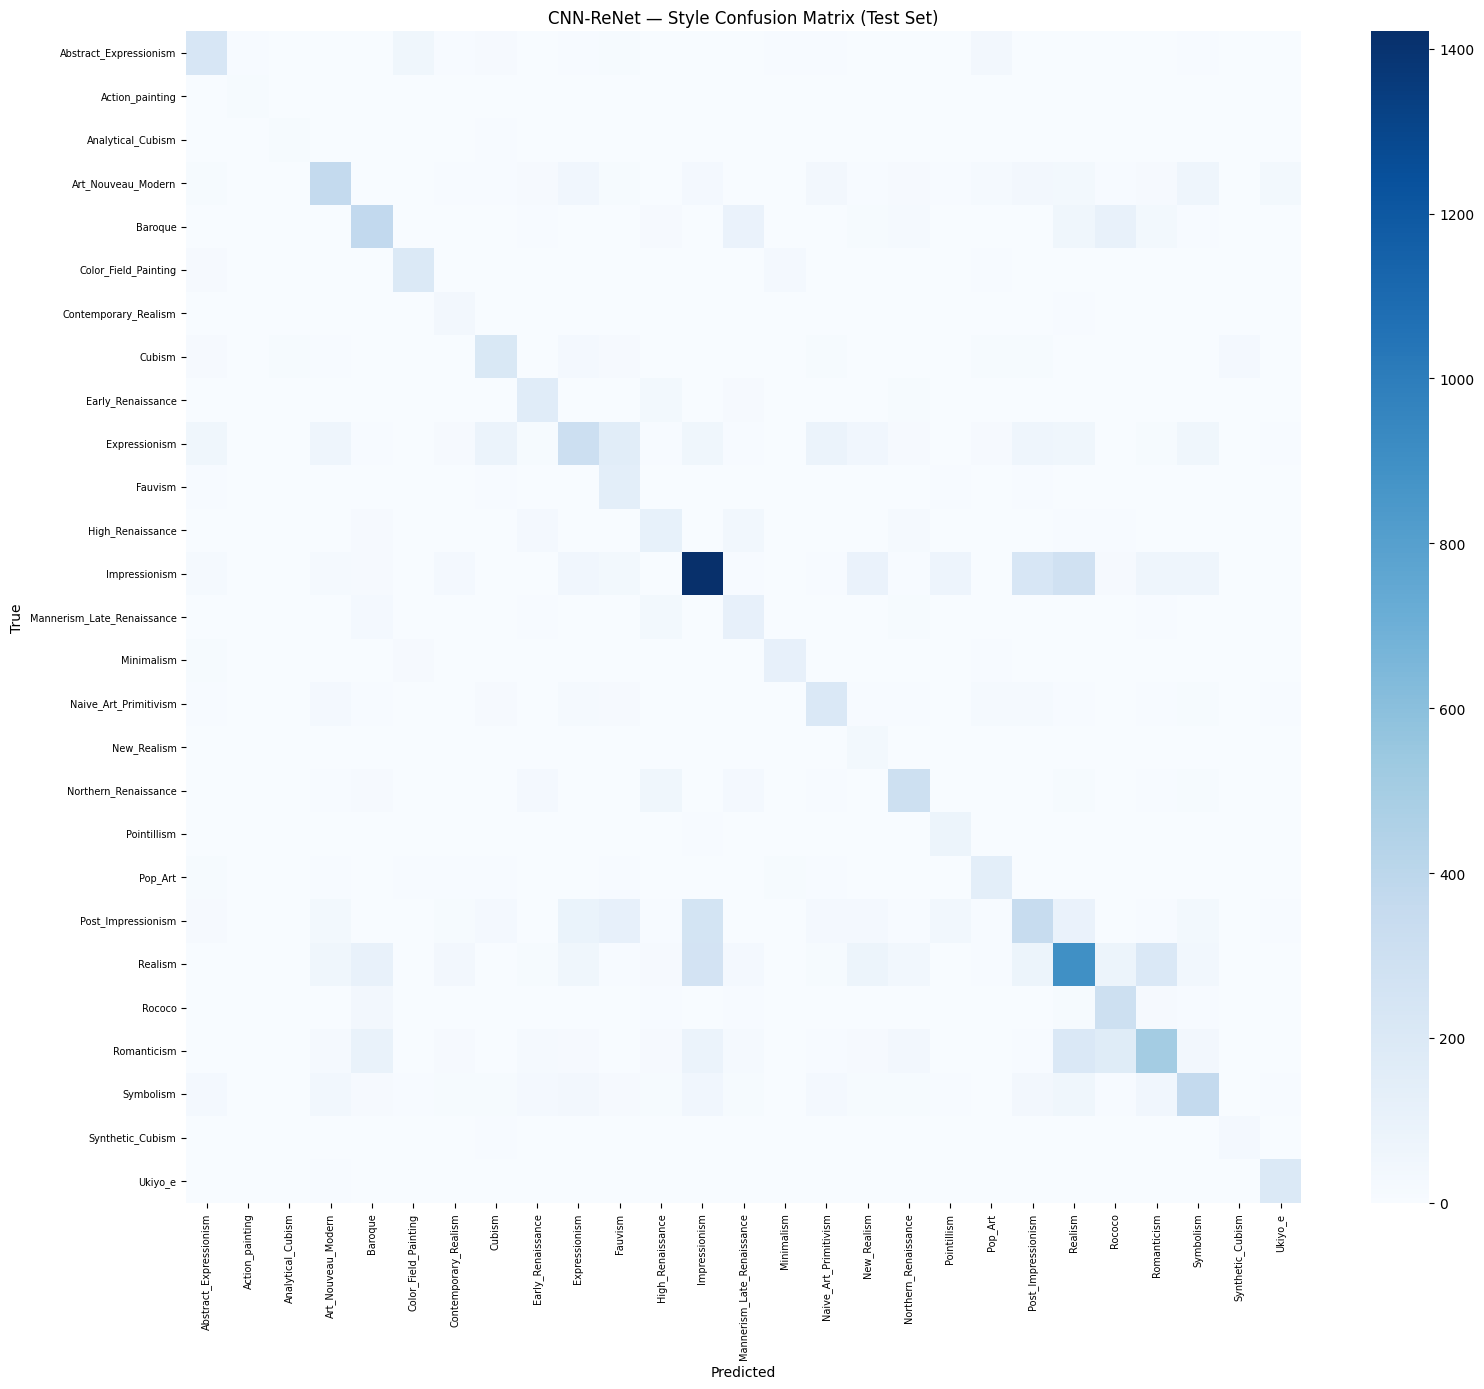


Top 15 most confused style pairs:
              true                       pred  count
     Impressionism                    Realism    288
           Realism              Impressionism    265
Post_Impressionism              Impressionism    258
     Impressionism         Post_Impressionism    228
           Realism                Romanticism    209
       Romanticism                    Realism    206
       Romanticism                     Rococo    168
     Expressionism                    Fauvism    158
Post_Impressionism                    Fauvism    117
           Realism                    Baroque    109
           Baroque                     Rococo    106
       Romanticism                    Baroque    105
           Baroque Mannerism_Late_Renaissance     98
     Impressionism                New_Realism     95
Post_Impressionism                    Realism     95


In [26]:
fig, ax = plt.subplots(figsize=(16, 14))
cm = confusion_matrix(style_true, style_pred)
sns.heatmap(
    cm, annot=False, cmap='Blues',
    xticklabels=le_style.classes_,
    yticklabels=le_style.classes_,
    ax=ax
)
ax.set_title('CNN-ReNet — Style Confusion Matrix (Test Set)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig('/kaggle/working/style_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the most confused pairs — more informative than the full matrix
print("\nTop 15 most confused style pairs:")
cm_df = pd.DataFrame(cm, index=le_style.classes_, columns=le_style.classes_)
np.fill_diagonal(cm_df.values, 0)  # zero out diagonal
confused = []
for true_class in cm_df.index:
    for pred_class in cm_df.columns:
        if cm_df.loc[true_class, pred_class] > 0:
            confused.append({
                'true':  true_class,
                'pred':  pred_class,
                'count': cm_df.loc[true_class, pred_class]
            })
confused_df = pd.DataFrame(confused).sort_values('count', ascending=False)
print(confused_df.head(15).to_string(index=False))

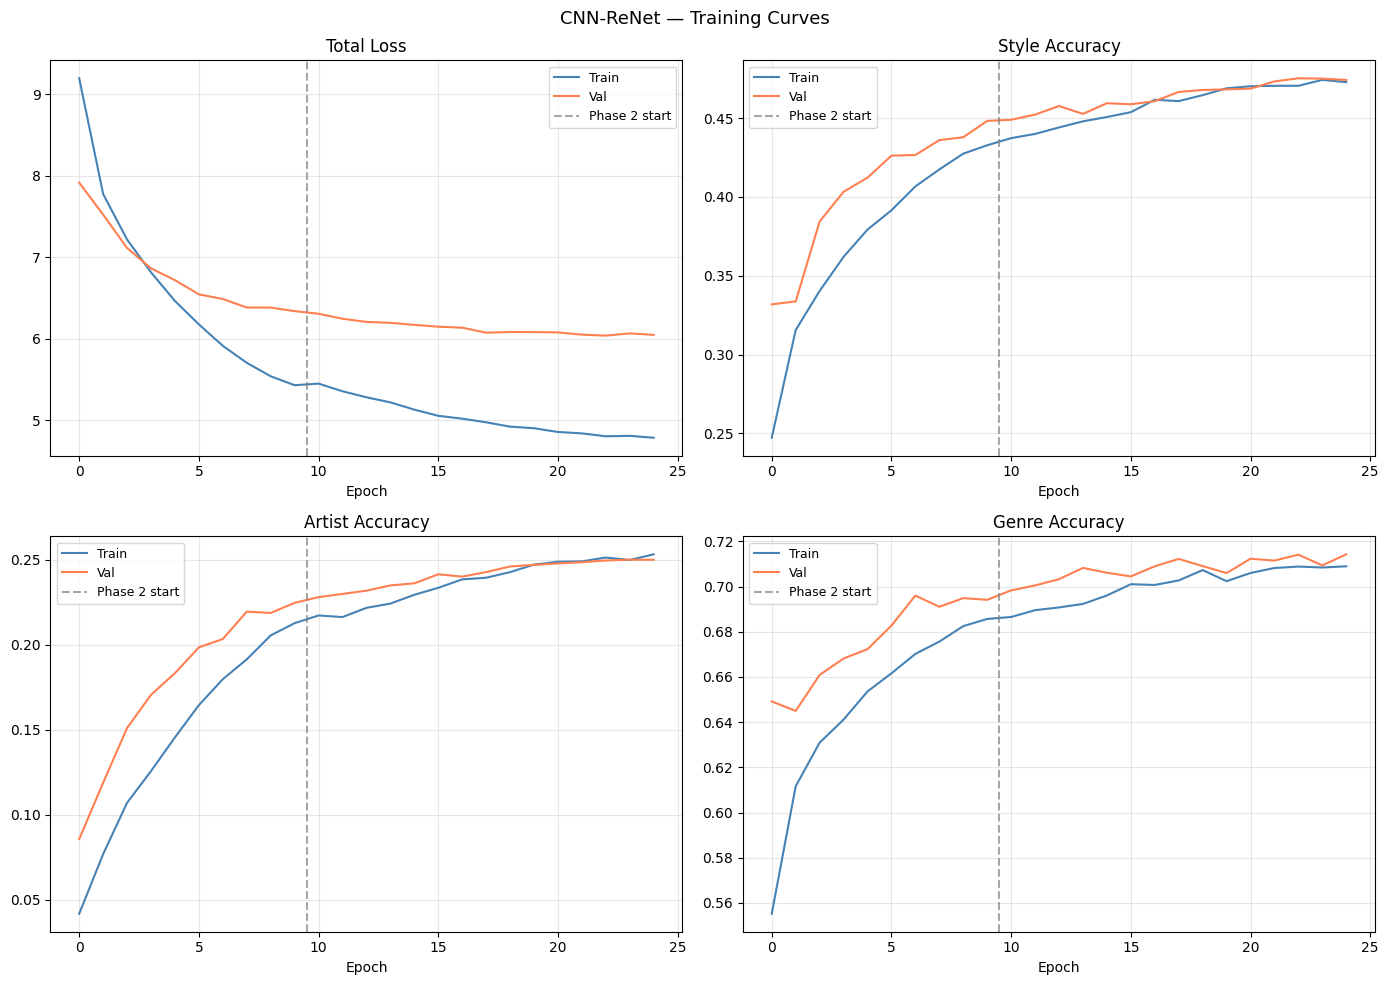

In [27]:
def plot_training_curves(history, model_name):
    metrics = ['loss', 'style_acc', 'artist_acc', 'genre_acc']
    titles  = ['Total Loss', 'Style Accuracy', 'Artist Accuracy', 'Genre Accuracy']

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    phase2_start = 10

    for ax, metric, title in zip(axes, metrics, titles):
        train_vals = [m[metric] for m in history['train']]
        val_vals   = [m[metric] for m in history['val']]

        ax.plot(train_vals, label='Train', color='steelblue')
        ax.plot(val_vals,   label='Val',   color='coral')
        ax.axvline(phase2_start - 0.5, color='gray', linestyle='--',
                   alpha=0.7, label='Phase 2 start')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle(f'{model_name} — Training Curves', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{model_name}_training_curves.png',
                dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves(history_renet, 'CNN-ReNet')

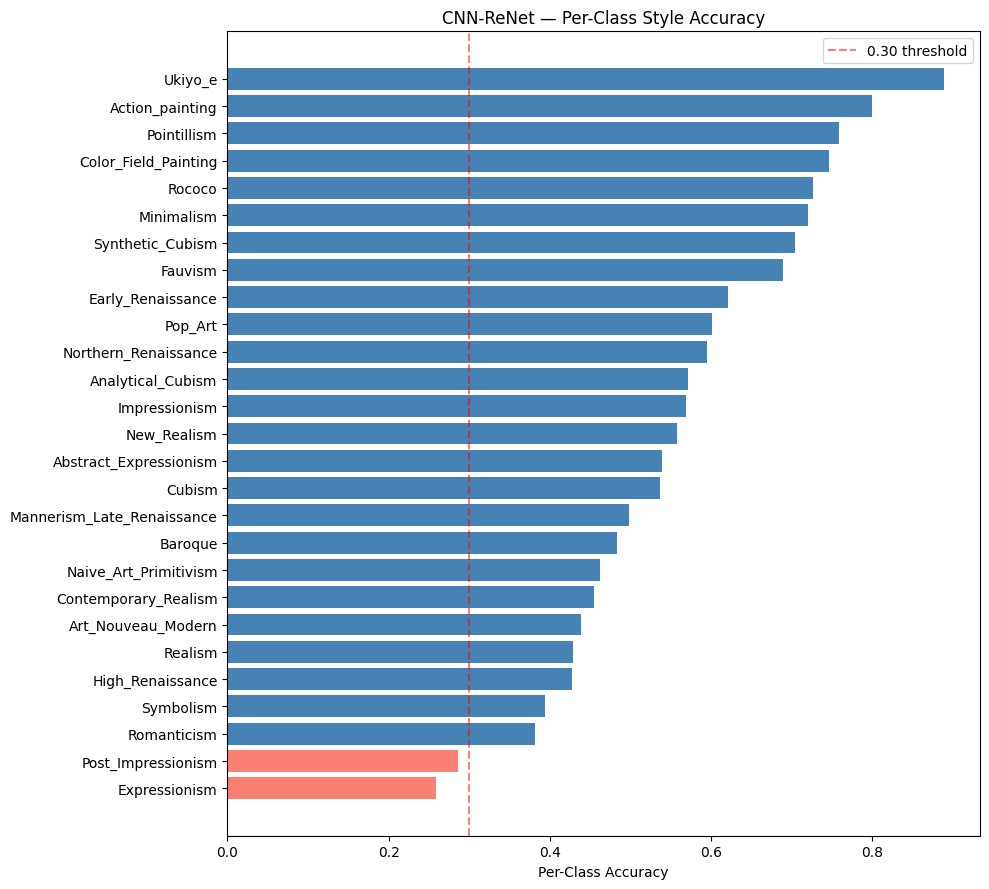


Worst performing styles:
                      accuracy
Expressionism         0.259136
Post_Impressionism    0.286661
Romanticism           0.381559
Symbolism             0.394105
High_Renaissance      0.428030
Realism               0.428777
Art_Nouveau_Modern    0.438257
Contemporary_Realism  0.454545

Best performing styles:
                      accuracy
Fauvism               0.689320
Synthetic_Cubism      0.704545
Minimalism            0.720238
Rococo                0.726392
Color_Field_Painting  0.746269
Pointillism           0.759259
Action_painting       0.800000
Ukiyo_e               0.889381


In [28]:
per_class_acc = {}
for idx, style_name in enumerate(le_style.classes_):
    mask = style_true == idx
    if mask.sum() > 0:
        per_class_acc[style_name] = (style_pred[mask] == idx).mean()

per_class_df = pd.DataFrame.from_dict(
    per_class_acc, orient='index', columns=['accuracy']
).sort_values('accuracy', ascending=True)

plt.figure(figsize=(10, 9))
bars = plt.barh(per_class_df.index, per_class_df['accuracy'],
                color=['salmon' if v < 0.3 else 'steelblue'
                       for v in per_class_df['accuracy']])
plt.axvline(0.3, color='red', linestyle='--', alpha=0.5, label='0.30 threshold')
plt.xlabel('Per-Class Accuracy')
plt.title('CNN-ReNet — Per-Class Style Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/per_class_style_accuracy.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nWorst performing styles:")
print(per_class_df.head(8).to_string())
print("\nBest performing styles:")
print(per_class_df.tail(8).to_string())